In [29]:
import matplotlib.pyplot as plt
import numpy
from scipy.integrate import quad
from tqdm import tqdm

Calculating g3
Calculating g2


100%|█████████████████████████████████████████████████████████████████████████████| 299/299 [00:00<00:00, 23424.86it/s]


Calculating g1


100%|███████████████████████████████████████████████████████████████████████████████| 299/299 [00:02<00:00, 113.41it/s]


Calculating g3sum


100%|██████████████████████████████████████████████████████████████████████████████| 300/300 [00:00<00:00, 4269.53it/s]


Calculating g


100%|████████████████████████████████████████████████████████████████████████████████| 299/299 [06:19<00:00,  1.27s/it]


Calculating f
Calculating f3


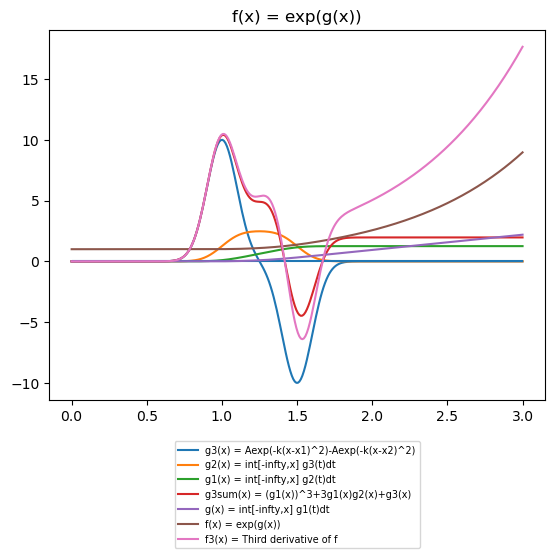

In [43]:
def npmap(f):
    def f_mapped(xx):
        return numpy.array([f(x) for x in tqdm(xx)])

    return f_mapped

# Returns a numpy array of values of the integral
def np_integral_graph(f,xx):    
    cur_int = quad(f,-numpy.inf,xx[0])[0]
    yy = [cur_int]
    prev_x = xx[0]
    for x in tqdm(xx[1:]):
        cur_int += quad(f,prev_x,x)[0]
        yy.append(cur_int)
        prev_x = x

    return numpy.array(yy)    

g3_desc = "g3(x) = Aexp(-k(x-x1)^2)-Aexp(-k(x-x2)^2)"
A = 10
k = 50
x1 = 1
x2 = 1.5
def g3(x):
    return A*numpy.exp(-k*(x-x1)*(x-x1))-A*numpy.exp(-k*(x-x2)*(x-x2))

g2_desc = "g2(x) = int[-infty,x] g3(t)dt"
def g2(x):
    return quad(g3,-numpy.inf,x)[0]

g2m = npmap(g2)

g1_desc = "g1(x) = int[-infty,x] g2(t)dt"
def g1(x):
    return quad(g2,-numpy.inf,x)[0]

g1m = npmap(g1)

g_desc = "g(x) = int[-infty,x] g1(t)dt"
def g(x):
    return quad(g1,-numpy.inf,x)[0]

gm = npmap(g)

f_desc = "f(x) = exp(g(x))"
def f(x):
    return numpy.exp(gm(x))

g3sum_desc = "g3sum(x) = (g1(x))^3+3g1(x)g2(x)+g3(x)"
def g3sum(x):
    return numpy.power(g1m(x),3)+3*g1m(x)*g2m(x)+g3(x)

f3_desc = "f3(x) = Third derivative of f"
def f3(x):
    return f(x)*g3sum(x)

min_x = 0
max_x = 3
n_points = 300
xx = numpy.linspace(min_x,max_x,n_points)
print("Calculating g3")
g3yy = g3(xx)
print("Calculating g2")
g2yy = np_integral_graph(g3,xx)
print("Calculating g1")
g1yy = np_integral_graph(g2,xx)
print("Calculating g3sum")
g3sumyy = g3sum(xx)
print("Calculating g")
gyy = np_integral_graph(g1,xx)
print("Calculating f")
fyy = numpy.exp(gyy)
print("Calculating f3")
f3yy = fyy*g3sumyy

plt.plot(xx,g3yy,label=g3_desc)
plt.plot(xx,g2yy,label=g2_desc)
plt.plot(xx,g1yy,label=g1_desc)
plt.plot(xx,g3sumyy,label=g3sum_desc)
plt.hlines(0,min_x,max_x)
plt.plot(xx,gyy,label=g_desc)
plt.plot(xx,fyy,label=f_desc)
plt.plot(xx,f3yy,label=f3_desc)
plt.title(f_desc)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), fontsize="x-small")
    
plt.show()